# Generar un dataset artificial utilizando ***NumPy***

In [1]:
import numpy as np

# Punto de intersección
a_real = 1.0

# Pendiente de la recta
b_real = 2.5

# Número de puntos del dataset
n = 50

# Valores máximos y mínimos de 'x'
x_min = 0
x_max = 10

# Generamos los valores de 'x' usando np.linspace
# np.linspace crea un array de números espaciados uniformemente sobre un intervalo
x_values = np.linspace(x_min, x_max, n)

# Generamos el ruido aleatorio usando np.random.uniform
# Genera 'n' muestras de ruido entre -10 y 10.
ruido = np.random.uniform(-10, 10, n)

# Calculamos los valores de 'y'
y_values = a_real + b_real * x_values + ruido

# 'x_values' y 'y_values' son ahora arrays de NumPy
print("Valores de X (NumPy):", x_values)
print("Valores de Y (NumPy):", y_values)

Valores de X (NumPy): [ 0.          0.20408163  0.40816327  0.6122449   0.81632653  1.02040816
  1.2244898   1.42857143  1.63265306  1.83673469  2.04081633  2.24489796
  2.44897959  2.65306122  2.85714286  3.06122449  3.26530612  3.46938776
  3.67346939  3.87755102  4.08163265  4.28571429  4.48979592  4.69387755
  4.89795918  5.10204082  5.30612245  5.51020408  5.71428571  5.91836735
  6.12244898  6.32653061  6.53061224  6.73469388  6.93877551  7.14285714
  7.34693878  7.55102041  7.75510204  7.95918367  8.16326531  8.36734694
  8.57142857  8.7755102   8.97959184  9.18367347  9.3877551   9.59183673
  9.79591837 10.        ]
Valores de Y (NumPy): [-1.59219777 -5.0367456  -5.19449489  5.61029111  9.41455705 -2.43378585
 -5.74331276  3.07778788 -2.49940301  0.65733215  2.69264526 12.24188665
  7.79099954  2.83527    17.42431186  8.11458225 17.90139157 16.9867883
  1.28694618  9.67030481 11.46469648 10.80266492  5.24638561 20.90062246
 14.3263243  17.98490088 11.98637449 24.34383797  9.296

# Mostrar gráfica con ***matplotlib***

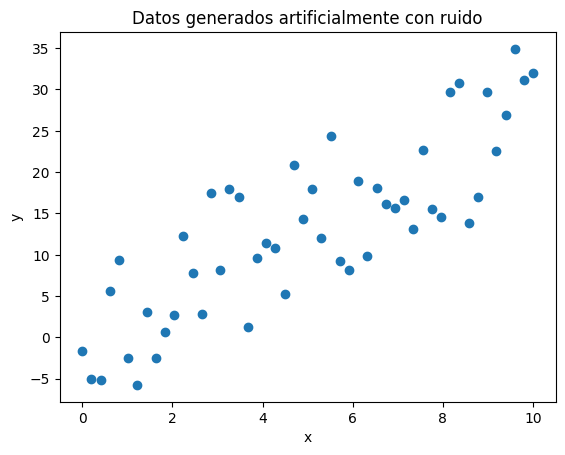

In [2]:
import matplotlib.pyplot as plt

# Creamos el gráfico de dispersión
plt.scatter(x_values, y_values)

# Añadimos etiquetas y título
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos generados artificialmente con ruido")

# Mostramos la gráfica
plt.show()

# Función para calcular el Error Cuadrático Medio usando ***NumPy***

In [3]:
# programar una funcion que calcule el error cuadratico medio segun la formula anterior

'''
Opción 1: Usando NumPy

def error_cuadratico_medio_np(x_values, y_values, a=0.0, b=0.0):
    # Número de muestras (n)
    n = len(y_values)

    # Predicción del modelo (h_values)
    h_values = a + b * x_values

    # Vector de errores (diferencia entre predicción e 'y' real)
    error_vector = h_values - y_values

    # Error Cuadrático Medio (MSE)
    error = np.sum(error_vector**2) / n
    return error
'''

# Opción 2: Usando NumPy

def error_cuadratico_medio(x_values, y_values):
    # Parámetros iniciales
    a = 0.0 # Punto de intersección inicial
    b = 0.0 # Pendiente de la recta inicial

    # Predicción del modelo
    h_values = a + b * x_values

    # Calculamos el error cuadrático medio
    error = np.mean((h_values - y_values) ** 2)

    return error

print(f"Error inicial: {error_cuadratico_medio(x_values, y_values):.2f}")

Error inicial: 280.10


# Descenso del Gradiente usando ***NumPy***

In [4]:
#Programar el algoritmo del descenso del gradiente para obtener la recta solución

import numpy as np

# Parámetros reales de 'a' y 'b'
# Punto de intersección
a_real = 1.0

# Punto de la recta
b_real = 2.5

# Número de puntos del dataset
n = 50

# Valores máximos y míminos de 'x'
x_min = 0
x_max = 10

# Generamos el dataset
x_values = np.linspace(x_min, x_max, n)
ruido = np.random.uniform(-10, 10, n)
y_values = a_real + b_real * x_values + ruido

# Parámetros iniciales
a = 0.0
b = 0.0

# Valor del rango de aprendizaje (alfa)
lr = 0.001

# Epsilon (criterio de parada)
epsilon = 0.00001

# Lista para registrar el error
errores = []

prev_error = float('inf')

# Número de iteraciones (ciclo de aprendizaje)
iteraciones = 10000

# Calculamos el Descenso del Gradiente
for i in range(iteraciones):
    # Calculamos valores de h
    h_values = a + b * x_values

    # Calculamos el vector de errores (h - y)
    error_vector = h_values - y_values

    # Calculamos derivada de error de 'a'
    da = lr * np.sum(error_vector)

    # Calculamos derivada de error de 'b'
    db = lr * np.sum(error_vector * x_values)

    # Actualizamos valores de 'a' y 'b'
    a -= da
    b -= db

    # Calculamos error cuadrático medio
    error = np.sum(error_vector**2) / n # Otra versión sería np.mean(error_vector ** 2)
    errores.append(error)

    # Comprobamos si el error cuadrático medio está bajando
    if i % 1000 == 0:
        print(f"Iteración {i}: a={a:.4f}, b={b:.4f}, Error={error:.4f}")

    # Comprobamos la convergencia con epsilon
    if abs(prev_error - error) < epsilon:
        print(f"\nConvergencia alcanzada en la iteración {i} con error {error:.6f}")
        break

    prev_error = error

# Resultado final
print("-" * 40)
print(f"Valores reales: a_real={a_real:.4f}, b_real={b_real:.4f}")
print(f"Valores finales (GD): a={a:.4f}, b={b:.4f}, Error={error:.6f}")

Iteración 0: a=0.6660, b=4.5468, Error=282.8506

Convergencia alcanzada en la iteración 264 con error 37.146845
----------------------------------------
Valores reales: a_real=1.0000, b_real=2.5000
Valores finales (GD): a=-0.6680, b=2.7997, Error=37.146845


# Mostrar gráficas con ***matplotlib***

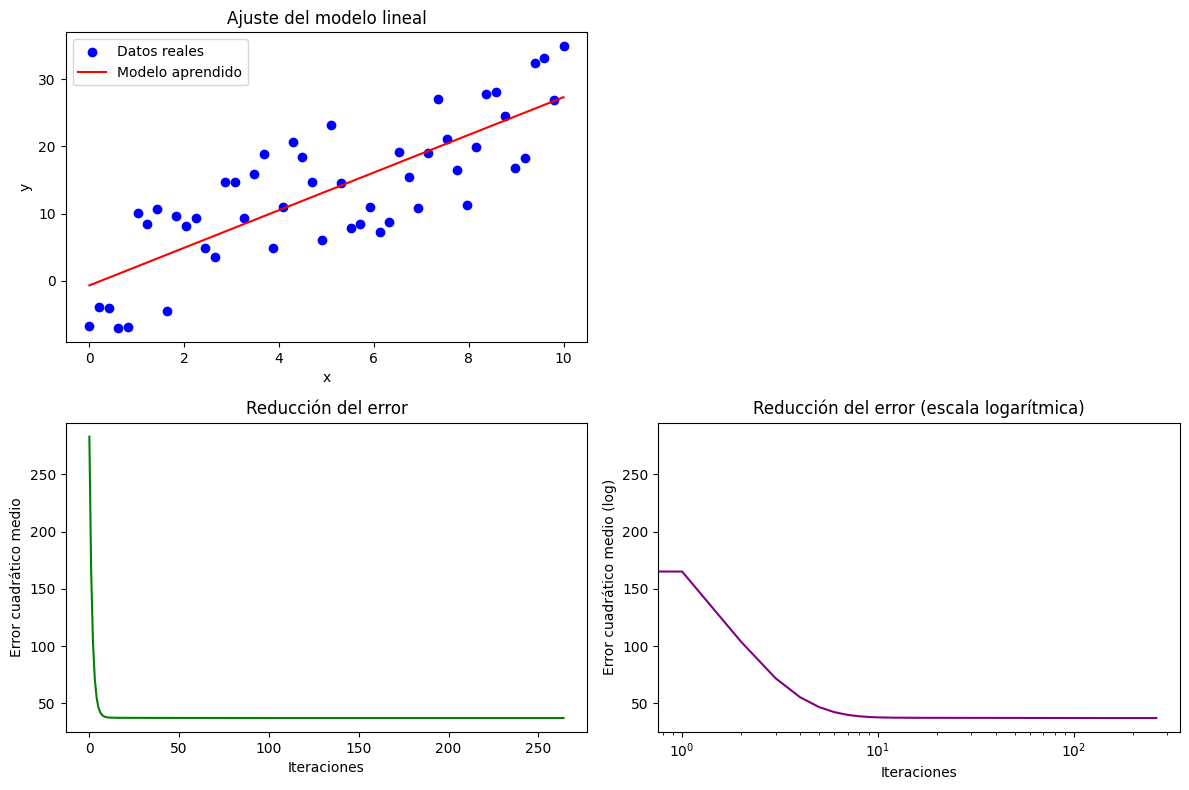

In [5]:
#Usando mathplotlib muestra la curva descrita en el parrafo anterior

import matplotlib.pyplot as plt

# Crear figura con 2 filas y 2 columnas
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Gráfica del modelo aprendido (fila 1, ocupa las 2 columnas)
axs[0, 0].scatter(x_values, y_values, color='blue', label='Datos reales')
axs[0, 0].plot(x_values, [a + b * x for x in x_values], color='red', label='Modelo aprendido')
axs[0, 0].set_xlabel('x')
axs[0, 0].set_ylabel('y')
axs[0, 0].set_title('Ajuste del modelo lineal')
axs[0, 0].legend()

# Ocultar el subplot vacío (posición [0,1]) ya que el de arriba ocupa todo el ancho
fig.delaxes(axs[0, 1])

# Gráfica del error normal (fila 2, columna 1)
axs[1, 0].plot(range(len(errores)), errores, color='green')
axs[1, 0].set_xlabel('Iteraciones')
axs[1, 0].set_ylabel('Error cuadrático medio')
axs[1, 0].set_title('Reducción del error')

# Gráfica del error logarítmico (fila 2, columna 2)
axs[1, 1].plot(range(len(errores)), errores, color='purple')
axs[1, 1].set_xscale('log')
axs[1, 1].set_xlabel('Iteraciones')
axs[1, 1].set_ylabel('Error cuadrático medio (log)')
axs[1, 1].set_title('Reducción del error (escala logarítmica)')

# Ajustar espacios
plt.tight_layout()
plt.show()

# Resumen y comparación de resultados

## Ajuste del modelo lineal
La primera gráfica muestra los datos generados artificialmente con ruido y la recta ajustada mediante el **descenso del gradiente**. Se puede observar que el modelo aprendido (en rojo) sigue de cerca la tendencia de los datos reales (en azul), lo que indica que el algoritmo ha encontrado valores de la pendiente `b` y la intersección `a` cercanos a los reales (`a_real=1.0`, `b_real=2.5`).

## Evolución del error
Las gráficas inferiores muestran cómo evoluciona el error cuadrático medio (ECM) a lo largo de las iteraciones:

- **Error normal**: Se observa una disminución constante del ECM hasta estabilizarse cerca de un valor mínimo, confirmando que el algoritmo converge.
- **Error en escala logarítmica**: Permite visualizar con mayor detalle la reducción del error en las etapas iniciales, mostrando cómo el ECM decrece rápidamente al inicio y luego se nivela a medida que el modelo se ajusta finamente.

## Comparación de resultados
- La recta aprendida aproxima correctamente los datos, similar a la función lineal real, aunque puede presentar pequeñas desviaciones debido al ruido.
- La reducción del error confirma que el descenso del gradiente optimizó los parámetros eficientemente.
- La escala logarítmica resalta la rapidez de convergencia inicial y el comportamiento asintótico del algoritmo.

## Ventajas de usar NumPy
- **Vectorización**: Permite realizar operaciones sobre todos los elementos de un array a la vez, evitando bucles explícitos y acelerando los cálculos.
- **Funciones optimizadas**: Operaciones como suma, promedio, multiplicación de vectores y exponenciación están altamente optimizadas en C.
- **Compatibilidad con algoritmos de ML**: Muchas librerías de aprendizaje automático y estadística están diseñadas para trabajar con arrays de NumPy, facilitando integración y eficiencia.
- **Facilidad de manejo de datos**: Generación de datasets (`linspace`, `random`), cálculo de errores (`mean`, operaciones vectorizadas) y manipulación de matrices es directa y clara.

En resumen, NumPy proporciona eficiencia, claridad y velocidad, haciendo que algoritmos como el **descenso del gradiente** sean mucho más sencillos y rápidos de implementar.
